In [71]:
# %%

from pathlib import Path
import importlib
import src.data_loading as exio
import src.analysis_tools as at
import seaborn as sns
import importlib
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
import seaborn as sns
import src.stimuli_timeline as st
import src.plotting as plott
import src.data_loading as exio
import src.analysis_tools as at
import importlib
import src.plotting as plott
importlib.reload(plott)



<module 'src.plotting' from 'C:\\Users\\larsch-lab\\code\\social_filters\\src\\plotting.py'>

In [72]:
# %%
### ==== CONFIG GENERAL (común a todos los peces) ===============================

experiment_name = "Exp_3_rocking_2"#"Exp_4_radius"#"Exp_2_rocking_1" #
main_path = Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p")
analysis_path= Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis")
stimuli_main_path = analysis_path
save_path= analysis_path / experiment_name / "plots"

fps_2p = 2.0
selected_blocks = [f"B{n}" for n in range(1, 5)]

t_pre_s  = 5.0   # time before onset to include
t_post_s = 32.0  # time after onset to include

# Lista de peces que quieres procesar
fish_ids = [
"L588_f01", # botton left
#"L588_f02", #top-right
"L588_f03", # botton left
"L654_f01", # botton left
"L654_f03" # botton left
]

importlib.reload(exio)
importlib.reload(at)

def load_and_align_one_fish(
    fish_id: str,
    experiment_name: str,
    main_path: Path,
    stimuli_main_path: Path,
    fps_2p: float,
    selected_blocks,
    t_pre_s: float,
    t_post_s: float,
):
    """Carga un experimento de un pez y calcula las trial-aligned traces.
    Devuelve TODO lo que quieres para usar después.
    """
    # ==== LOAD EVERYTHING IN ONE GO =========================================
    results = exio.load_2p_experiment(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
    )

    dfof              = results["dfof"]
    stimuli_trace_60  = results["stimuli_trace_60"]
    stimuli_id_map    = results["stimuli_id_map"]
    raster            = results["raster"]
    dfof_center       =results["deltaF_center"]
    dFoF_merged_map    =   results["dFoF_merged_map"]
    stimuli_durations = results["stimuli_durations"]
    kept_neuron_indices = results["kept_neuron_indices"]
    z_traces = results["z_traces"]
        # NEW: normalizar dfof_center a [0, 1] globalmente
    min_val = np.nanmin(dfof_center)          # NEW
    max_val = np.nanmax(dfof_center)          # NEW
    rng = max_val - min_val + 1e-12           # NEW (evita división por cero)

    dfof_center_norm = (dfof_center - min_val) / rng   # NEW


    # ==== BUILD TRIAL-ALIGNED TRACES ========================================
    res = at.build_trial_aligned_traces(
        dfof=dfof,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )



    # ==== BUILD TRIAL-ALIGNED TRACES Signf========================================
    res_raster = at.build_trial_aligned_traces(
        dfof=raster,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # ==== BUILD TRIAL-ALIGNED Z-core =======================================
    res_zcore = at.build_trial_aligned_traces(
        dfof=z_traces,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    ##==== BUILD TRIAL-ALIGNED Norm_Df/F========================================

    res_norm = at.build_trial_aligned_traces(
        dfof=dfof_center_norm,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    return {
        "trial_aligned_traces": res["trial_aligned_traces"],  # dict: stim_id -> (n_neurons, n_trials, frames)
        "stimuli_ids":          res["stimuli_ids"],           # list
        "stimuli_names":        res["stimuli_names"],         # list
        "win_length":           res["win_length"],            # int
        "stimuli_trace":        res["stimuli_trace"],         # (n_frames_total,)
        "onsets_by_id":         res["onsets_by_id"],          # dict: stim_id -> (n_trials,)
        "trial_aligned_traces_raster": res_raster["trial_aligned_traces"],
        "trial_aligned_traces_norm": res_norm["trial_aligned_traces"],
        "trial_aligned_traces_z_core": res_zcore["trial_aligned_traces"],
        # row data
        "dfof":                  dfof,
        "raster":                raster,
        "dfof_center":           dfof_center,
        "dFoF_merged_map":       dFoF_merged_map,
        "stimuli_durations":     stimuli_durations,
        "kept_neuron_indices":   kept_neuron_indices,
        "stimuli_id_map":         stimuli_id_map,
        # si más tarde quieres acceder a cosas del results original:
        "meta": {
            "frames_per_block":       results["frames_per_block"],
            "duration_2p_block_sec":  results["duration_2p_block_sec"],
            "paths":                  results["paths"],
            "plane_ids":              results["plane_ids"],
            "stat_per_plane":         results["stat_per_plane"],
            # etc, añade aquí lo que te haga falta
        }
    }


# ==== PROCESAR TODOS LOS PECES ==============================================
all_fish_data = {}

for fish_id in fish_ids:
    print(f"\n=== Procesando pez {fish_id} ===")
    all_fish_data[fish_id] = load_and_align_one_fish(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
    )

print("Listo, todos los peces procesados.")



=== Procesando pez L588_f01 ===
✅ Loaded significant traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L588_f01_Exp_3_rocking_2\03_analysis\functional\plots\significant_traces\L588_f01_significant_traces.npz
✅ Loaded kept_neuron_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L588_f01_Exp_3_rocking_2\03_analysis\functional\plots\filtered_neurons_by_stimuli\L588_f01_kept_neuron_indices.npy
✅ Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L588_f01_Exp_3_rocking_2\03_analysis\functional\suite2P\merged_dFoF\L588_f01_dFoF_merged_filtered_roi_indices.npy
✅ Loaded z_traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L588_f01_Exp_3_rocking_2\03_analysis\functional\plots\z_core\L588_f01_zcore.npz
dFoF_merged_map: (1133, 6)
Loaded planes: ['plane0', 'plane1', 'plane2', 'plane3', 'plane4']
✅ Using preferred dFoF file: D:\Alejandro\Data\OneDrive - Université de Lausann

In [73]:

# select colors and linestyles for stimuli
# --- Set A (default)

colors_C = {
    'RiB': sns.color_palette('dark:#404040', 10)[7],
    'LeB': sns.color_palette('dark:#404040', 10)[7],
    'Ri1F': sns.color_palette('Blues', 8)[7],
    'Ri2F': sns.color_palette('Greens', as_cmap=True)(0.4),
    'DRiF': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'Le1F': sns.color_palette('Blues', 8)[7],
    'Le2F': sns.color_palette('Greens', as_cmap=True)(0.4),
    'DLeF': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'BiF1': sns.color_palette('Reds', as_cmap=True)(0.9),
    'BiF2': sns.color_palette('Reds', as_cmap=True)(0.9),
    'RiR': sns.color_palette('Greens', as_cmap=True)(0.9),
    'LeR': sns.color_palette('Greens', as_cmap=True)(0.9),
    'BiR1': sns.color_palette('PuRd', as_cmap=True)(0.6),
    'BiR2': sns.color_palette('PuRd', as_cmap=True)(0.6),

}
linestyles_C = {
    'RiB': '--',
    'Ri1F': '--',
    'Ri2F': '--',
    'DRiF': '--',
    'BiF1': '--',
    'RiR': '--',
    'BiR1': '--',
}

stimuli_colors = colors_C
stimuli_linestyles = linestyles_C

# --- choose stimulus-aligned windows ---
window_pre = 5  # seconds before stimulus
window_post = 17  # seconds after stimulus

stimuli_ordered = ['RiB',
                   'LeB',
                   'Ri1F',
                   'Ri2F',
                   'DRiF',
                   'Le1F',
                   'Le2F',
                   'DLeF',
                   'BiF1',
                   'BiF2',
                   'RiR',
                   'LeR',
                   'BiR1',
                   'BiR2',

                   ]
print("Using colors for:", experiment_name)
print(stimuli_linestyles)

Using colors for: Exp_3_rocking_2
{'RiB': '--', 'Ri1F': '--', 'Ri2F': '--', 'DRiF': '--', 'BiF1': '--', 'RiR': '--', 'BiR1': '--'}


In [74]:
import sys

print(sys.version)
print(sys.executable)

3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]
C:\ProgramData\miniconda3\envs\social_filters\python.exe


In [75]:
def combine_reps_one_stim(arr, mode="concat"):
    """
    arr: (n_neurons, n_time, n_reps)
    mode: "concat" or "mean"

    Returns:
        if mode == "concat": (n_neurons, n_time * n_reps)
        if mode == "mean":   (n_neurons, n_time)
    """
    assert arr.ndim == 3, "Expected 3D array (neurons, time, reps)"
    n_neurons, n_time, n_reps = arr.shape

    if mode == "concat":
        # (N, T, R) -> (N, R, T) -> (N, R*T)
        arr_swapped = np.swapaxes(arr, 1, 2)          # (n_neurons, n_reps, n_time)
        out = arr_swapped.reshape(n_neurons, n_reps * n_time)
        return out

    elif mode == "mean":
        # average across reps axis
        out = np.nanmean(arr, axis=2)                 # (n_neurons, n_time)
        return out

    else:
        raise ValueError(f"Unknown mode '{mode}', use 'concat' or 'mean'")


def build_matrix_for_fish(trial_aligned_traces,
                          stim_order,
                          kept_neuron_indices=None,
                          combine_mode="concat"):
    """
    trial_aligned_traces: dict[stim_id] -> array (neurons, time, reps)
    stim_order: list with desired stimulus order
    kept_neuron_indices: 1D array/list of neuron indices to keep, or None
    combine_mode: "concat" or "mean"
    """
    blocks = []

    for stim in stim_order:
        # Handle int vs str keys
        if stim in trial_aligned_traces:
            arr = trial_aligned_traces[stim]
        else:
            arr = trial_aligned_traces[str(stim)]

        # 🔴 HERE we apply your kept_neuron_indices
        if kept_neuron_indices is not None:
            arr = arr[kept_neuron_indices, :, :]

        arr_block = combine_reps_one_stim(arr, mode=combine_mode)  # (N, T*reps)
        blocks.append(arr_block)

    # Concatenate horizontally along time
    fish_mat = np.concatenate(blocks, axis=1)   # (N, sum_j T_j * reps_j)
    return fish_mat

def build_matrix_all_fish(
    all_fish_data,
    stim_order,
    fish_ids=None,
    combine_mode="concat",
    trace_type="dfof",
):
    """
    all_fish_data[fish_id][...] -> dict[stim] -> (neurons, time, reps)

    Parameters
    ----------
    all_fish_data : dict
        Per-fish data container.
    stim_order : list
        Stimulus order to use when building the matrix.
    fish_ids : list, optional
        Fish IDs to include. If None, use all fish in all_fish_data.
    combine_mode : str, default="concat"
        Passed to build_matrix_for_fish.
    trace_type : str, default="dfof"
        Which trace representation to use:
        - "dfof"   -> trial_aligned_traces
        - "raster" -> trial_aligned_traces_raster
        - "zscore" -> trial_aligned_traces_z_core

    Returns
    -------
    M_all : np.ndarray
        Shape (sum_neurons_all_fish, total_time)
    """
    if fish_ids is None:
        fish_ids = list(all_fish_data.keys())

    mats = []
    for fid in fish_ids:

        if trace_type == "raster":
            trial_key = "trial_aligned_traces_raster"
            kept_idx = None   # already filtered for raster version

        elif trace_type == "zscore":
            trial_key = "trial_aligned_traces_z_core"
            kept_idx = all_fish_data[fid]["kept_neuron_indices"]

        elif trace_type == "dfof":
            trial_key = "trial_aligned_traces"
            kept_idx = all_fish_data[fid]["kept_neuron_indices"]

        else:
            raise ValueError(
                f"Unknown trace_type={trace_type!r}. "
                "Use 'dfof', 'raster', or 'zscore'."
            )

        trial_aligned_traces = all_fish_data[fid][trial_key]

        M_fish = build_matrix_for_fish(
            trial_aligned_traces=trial_aligned_traces,
            stim_order=stim_order,
            kept_neuron_indices=kept_idx,
            combine_mode=combine_mode,
        )
        mats.append(M_fish)

    M_all = np.vstack(mats)

    return M_all

In [77]:
fish_id = fish_ids[1]
trial_aligned_traces = all_fish_data[fish_id]["trial_aligned_traces"]
stimuli_id_map = all_fish_data[fish_id]["stimuli_id_map"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
stimuli_ids = all_fish_data[fish_id]["stimuli_ids"]
stimuli_names = all_fish_data[fish_id]["stimuli_names"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
onsets_by_id = all_fish_data[fish_id]["onsets_by_id"]


Final matrix shape: (1687, 4144)


Final matrix shape: (1347, 148)
✅ Saved: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis\Exp_3_rocking_2\plots\L588_f03_dfof_as_func_of_time_pca.png


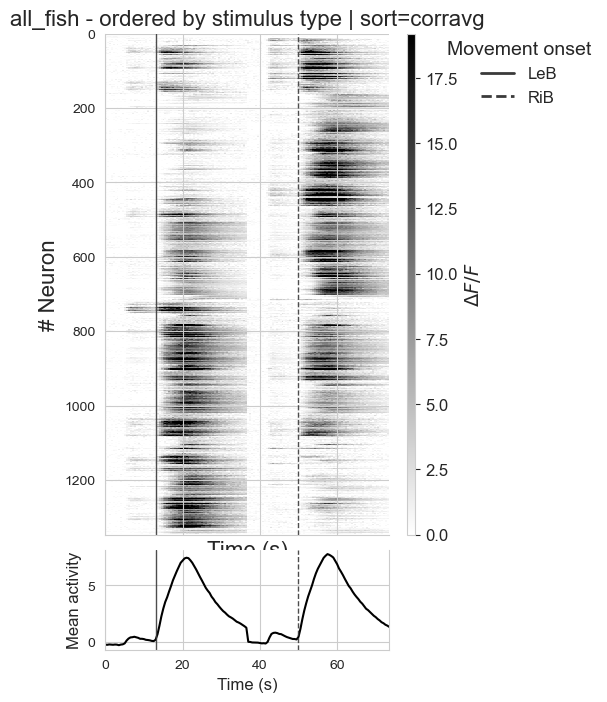

In [80]:
# plot all fish together
#{'BiF1': 1, 'BiF2': 2, 'BiR1': 3, 'BiR2': 4, 'DLeF': 5, 'DRiF': 6, 'Le1F': 7, 'Le2F': 8, 'LeB': 9, 'LeR': 10, 'Ri1F': 11, 'Ri2F': 12, 'RiB': 13, 'RiR': 14}

#stim_order = [13,11,12,6,1,14,3]
stim_order = [9,13]
combine_mode = "mean"  # mean or concat
trace_type =  "zscore" #  "dfof" ,  "raster" , zscore" -> trial_aligned_traces
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, trace_type=trace_type)
print("Final matrix shape:", M_all.shape)

# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)
flat_matrix_all_fish = M_all  # (time, neurons) for raster_with_stimuli


fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='corravg',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=None,       # or pass your own `neuron_order`
    sort_label=None,         # optional label override
    is_binary=False,         # True if you pass a 0/1 significance matrix
    show_mean_trace=True,
    figsize=(4, 8),
    fish_id="all_fish",
)


save_path.mkdir(parents=True, exist_ok=True)
out_png = save_path / f"{fish_id}_dfof_as_func_of_time_pca.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
print("✅ Saved:", out_png)


In [33]:
## i just use the same funtons and run per fish to generate a bigger matrix...

In [44]:
## Organize by Left and Rigth response....
## First Concatenate mean traces across experiments
import numpy as np

# result: concat_mean_traces[stim] -> (sum_fish n_kept_neurons_fish, win_length)
concat_mean_traces = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons_norm = {stim: [] for stim in stimuli_ids}

for fid in fish_ids:
    trial_aligned_traces = all_fish_data[fid]["trial_aligned_traces"]
    trial_aligned_traces_norm = all_fish_data[fid]["trial_aligned_traces_norm"]
    kept_neuron_indices = all_fish_data[fid]["kept_neuron_indices"]

    for stim in stimuli_ids:
        X = trial_aligned_traces[stim]              # (n_neurons, win_length, n_trials)
        Xkept = X[kept_neuron_indices, :, :]        # (n_kept_fish, win_length, n_trials)
        mean_trace = np.nanmean(Xkept, axis=2)     # (n_kept_fish, win_length)
        mean_all_neurons = np.nanmean(mean_trace, axis=0)

        concat_mean_traces[stim].append(mean_trace)
        concat_mean_all_neurons[stim].append(mean_all_neurons)

        Y = trial_aligned_traces_norm[stim]        # same as X but Global Norm
        mean_trace_norm = np.nanmean(Y, axis=2)
        mean_all_neurons_norm = np.nanmean(mean_trace_norm, axis=0)

        concat_mean_all_neurons_norm[stim].append(mean_all_neurons_norm)
# stack per stimulus along the neuron axis
for stim in stimuli_ids:
    concat_mean_traces[stim] = np.vstack(concat_mean_traces[stim])
    concat_mean_all_neurons[stim] = np.vstack(concat_mean_all_neurons[stim])
    concat_mean_all_neurons_norm[stim] = np.vstack(concat_mean_all_neurons_norm[stim])
# Example:
# big_mat_FL1 = concat_mean_traces['FL1']   # shape: (all_kept_neurons_all_fish, win_length)
print(concat_mean_all_neurons[stim].shape)
print(concat_mean_traces[stim].shape)

(5, 74)
(1687, 74)


In [45]:
pre_frames  = int(round(t_pre_s * fps_2p))
post_frames = int(round(t_post_s * fps_2p))
win_lenght = pre_frames + post_frames
frame_window = (pre_frames, win_lenght)
L, R, TI = at.compute_left_right_index(
    mean_traces=concat_mean_traces,
    left_stim=9,   # e.g., FLB = 4
    right_stim=13,
    frame_window=frame_window,
    kept_cells=None,   # or None
)

RL_neuro_order= np.argsort(TI)

In [58]:
print(flat_matrix_all_fish.shape)

(1687, 2072)


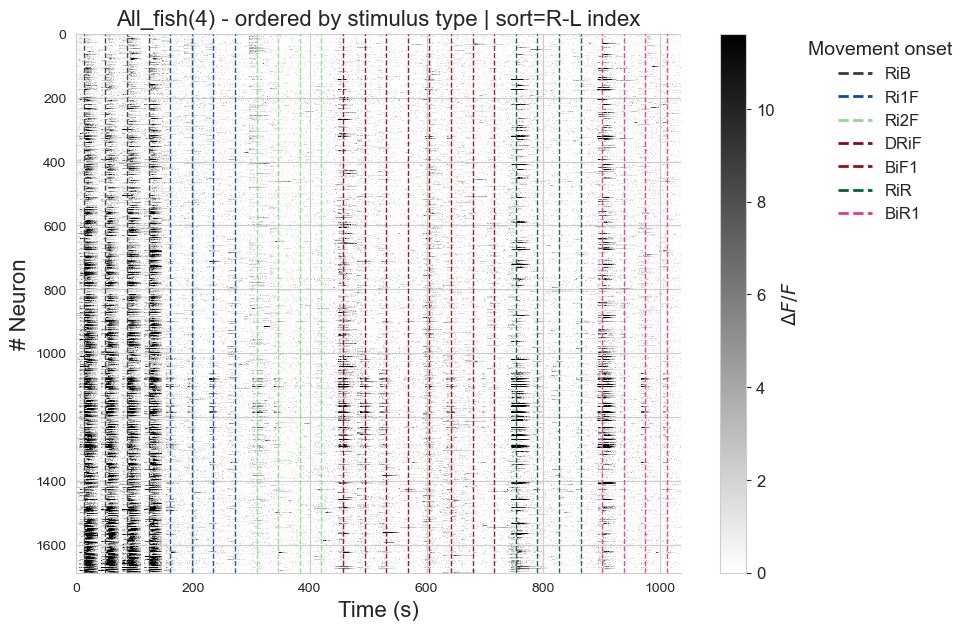

In [54]:
# plot all fish together
#{'BiF1': 1, 'BiF2': 2, 'BiR1': 3, 'BiR2': 4, 'DLeF': 5, 'DRiF': 6, 'Le1F': 7, 'Le2F': 8, 'LeB': 9, 'LeR': 10, 'Ri1F': 11, 'Ri2F': 12, 'RiB': 13, 'RiR': 14}

stim_order = [13,11,12,6,1,14,3]
combine_mode = "concat"  # mean or concat
trace_type =  "zscore" #  "dfof" ,  "raster" , zscore" -> trial_aligned_traces
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, trace_type=trace_type)
flat_matrix_all_fish = M_all   # (time, neurons) for raster_with_stimuli

fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='pca',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=RL_neuro_order,
    show_mean_trace=False,# or pass your own `neuron_order`
    sort_label='R-L index',         # optional label override
    is_binary=False,         # True if you pass a 0/1 significance matrix
    figsize=(10, 7),
    fish_id="All_fish(5)",
)

# save_path.mkdir(parents=True, exist_ok=True)
# if is_raster is False:
#     out_png = save_path / f"delta_as_func_of_time_just_bouts_average.png"
# else:
#    out_png = save_path / f"binary_as_func_of_time_just_bouts_average.png"
# fig.savefig(out_png, dpi=600, bbox_inches="tight")
# print("✅ Saved:", out_png)

new_stimuli_ids:   [13, 11, 12, 6, 1, 14, 3]
new_stimuli_names: ['RiB', 'Ri1F', 'Ri2F', 'DRiF', 'BiF1', 'RiR', 'BiR1']
shape of first M: (5, 74)


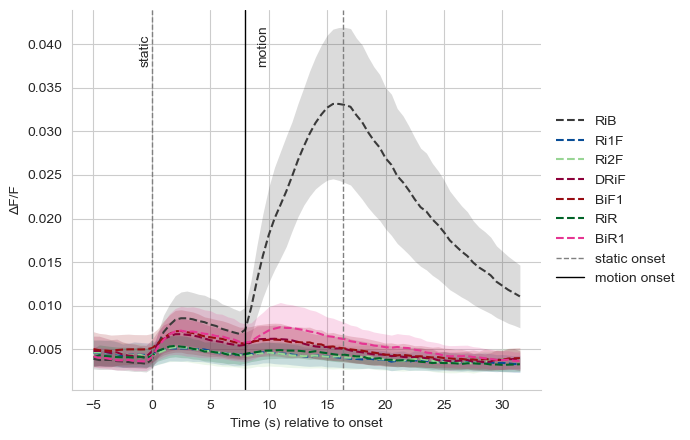

In [68]:
#### identify if
#Stimuli IDs: [1, 2, 3, 4, 5, 6, 7, 8]
#Stimuli names: ['LBb', 'LBc', 'LBd', 'LB', 'RBb', 'RBc', 'RBd', 'RB']
stim_order = [4,1,2,3,8,5,6,7]


#{'LB': 1, 'RB': 2, 'RL1': 3, 'RL2': 4, 'RL3': 5, 'RLR1': 6, 'RLR2': 7, 'RR1': 8, 'RR2': 9, 'RR3': 10}

#stimuli_wanted = [0,1,2,3,4,7,8,9,5,6]  # positions in the list (0-based!)
stimuli_wanted = [12,10,11,5,0,13,2]## rigth
# stimuli_wanted = [4,1,2,3] ## left
M = {}  # new dict with selected mean_traces
new_stimuli_ids = []  # new list of ids
new_stimuli_names = []  # new list of names

for pos in stimuli_wanted:
    # id in your list at that position
    stim_id = stimuli_ids[pos]
    stim_name = stimuli_names[pos]

    # take the correct array from the dict
    M[stim_id] = concat_mean_all_neurons[stim_id]

    # store id and name in new lists
    new_stimuli_ids.append(stim_id)
    new_stimuli_names.append(stim_name)

print("new_stimuli_ids:  ", new_stimuli_ids)
print("new_stimuli_names:", new_stimuli_names)
# example: check one of the matrices
print("shape of first M:", M[new_stimuli_ids[0]].shape)


fig, ax, used_colors, out_path = plott.plot_stimulus_means(
    mean_traces=M,
    stimuli_ids=new_stimuli_ids,
    stimuli_names=new_stimuli_names,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=t_post_s,
    t_pre_s=t_pre_s,
    stimuli_durations= stimuli_durations,
    plots_path=None,       # Path object or str
    prefix=None,               # e.g., "exp12_mouseA"
    dpi=600,
    save=False,
    stimuli_colors=stimuli_colors,            # <— pass styles here
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells = None,
    comment="jhghjg" # for saving
)



C:\Users\larsch-lab\AppData\Local\Temp\ipykernel_35292\2844875416.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_per_fish = np.trapz(seg, dx=dt, axis=1)   # (n_fish,)


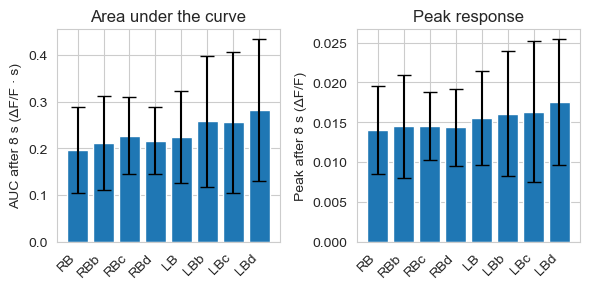

In [38]:
# stimuli_wanted = [0,2,3,4,5,6] # positions in the list (0-based!)

M = {}  # new dict with selected mean_traces
new_stimuli_ids = []  # new list of ids
new_stimuli_names = []  # new list of names

for pos in stimuli_wanted:
    # id in your list at that position
    stim_id = stimuli_ids[pos]
    stim_name = stimuli_names[pos]

    # take the correct array from the dict
    M[stim_id] = concat_mean_all_neurons[stim_id]   # (n_fish, n_frames)

    # store id and name in new lists
    new_stimuli_ids.append(stim_id)
    new_stimuli_names.append(stim_name)

# ---------- NEW: compute AUC and peak after 9 s & store per fish ----------
import numpy as np       # NEW
import matplotlib.pyplot as plt  # NEW

t_after = 8.0            # NEW (seconds)
dt = 1.0 / fps_2p        # NEW
frame_9s = int(round(t_after * fps_2p))  # NEW: frame index for 9 s

auc_means = []           # NEW
auc_sems = []            # NEW
peak_means = []          # NEW
peak_sems = []           # NEW

auc_values = {}          # NEW: guarda AUC por pez para cada estímulo
peak_values = {}         # NEW: guarda pico por pez para cada estímulo

for stim_id in new_stimuli_ids:          # NEW
    traces = M[stim_id]                  # shape (n_fish, n_frames)
    if traces.ndim == 1:                 # NEW (por si acaso)
        traces = traces[None, :]

    n_fish, n_frames = traces.shape      # NEW
    if frame_9s >= n_frames:             # NEW: sanity check
        raise ValueError(
            f"9 s (frame {frame_9s}) está fuera del rango "
            f"para el estímulo {stim_id} con {n_frames} frames."
        )

    seg = traces[:, frame_9s:]           # NEW: todo lo que pasa después de 9 s

    # --- Área bajo la curva (AUC) por pez ---  # NEW
    auc_per_fish = np.trapz(seg, dx=dt, axis=1)   # (n_fish,)
    # --- Pico después de 9 s por pez ---       # NEW
    peak_per_fish = np.nanmax(seg, axis=1)        # (n_fish,)

    # Guarda para análisis estadístico        # NEW
    auc_values[stim_id] = auc_per_fish           # NEW
    peak_values[stim_id] = peak_per_fish         # NEW

    # Medias y SEM para el bar plot            # NEW
    auc_means.append(np.nanmean(auc_per_fish))
    peak_means.append(np.nanmean(peak_per_fish))

    if n_fish > 1:
        auc_sems.append(np.nanstd(auc_per_fish, ddof=1) / np.sqrt(n_fish))
        peak_sems.append(np.nanstd(peak_per_fish, ddof=1) / np.sqrt(n_fish))
    else:
        auc_sems.append(0.0)
        peak_sems.append(0.0)

auc_means = np.array(auc_means)       # NEW
auc_sems = np.array(auc_sems)         # NEW
peak_means = np.array(peak_means)     # NEW
peak_sems = np.array(peak_sems)       # NEW

# ---------- (igual que antes) bar plots with SEM ----------
x = np.arange(len(new_stimuli_ids))   # NEW

fig, axes = plt.subplots(1, 2, figsize=(6,3), sharex=True)  # NEW

# AUC bar plot
axes[0].bar(x, auc_means, yerr=auc_sems, capsize=5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(new_stimuli_names, rotation=45, ha="right")
axes[0].set_ylabel("AUC after 8 s (ΔF/F · s)")
axes[0].set_title("Area under the curve")

# Peak bar plot
axes[1].bar(x, peak_means, yerr=peak_sems, capsize=5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(new_stimuli_names, rotation=45, ha="right")
axes[1].set_ylabel("Peak after 8 s (ΔF/F)")
axes[1].set_title("Peak response")

fig.tight_layout()
plt.show()


In [25]:
###  ---------- NEW: statistics (ANOVA / Kruskal + post-hoc) ----------  # CHANGED (EN)
from scipy import stats  # NEW
import itertools  # NEW
from statsmodels.stats.multicomp import \
    pairwise_tukeyhsd  # NEW (pip install statsmodels if you don't have it)  # CHANGED (EN)

###
alpha = 0.05  # NEW
labels = new_stimuli_names  # NEW (for pretty printing)  # CHANGED (EN)


def run_oneway_tests(values_dict, metric_name="AUC"):  # NEW
    """
    values_dict: dict[stim_id] -> array(shape (n_fish,))
    metric_name: only for printing ('AUC' or 'Peak')    # CHANGED (EN)
    """
    groups = [values_dict[stim_id] for stim_id in new_stimuli_ids]
    n_groups = len(groups)

    print(f"\n===== {metric_name}: one-way comparison across stimuli =====")  # NEW

    # --- Normality per group (Shapiro) ---   # NEW  # CHANGED (EN)
    normal_flags = []
    for stim_id, g in zip(new_stimuli_ids, groups):
        g = np.asarray(g)
        if len(g) >= 3:
            stat, p_norm = stats.shapiro(g)
            print(f"Shapiro {metric_name} - {stim_id}: p = {p_norm:.3f}")
        else:
            p_norm = 1.0  # with very few fish Shapiro is unreliable, assume normal  # CHANGED (EN)
            print(f"Shapiro {metric_name} - {stim_id}: N={len(g)}, skip (assume normal)")  # CHANGED (EN)
        normal_flags.append(p_norm > alpha)

    all_normal = all(normal_flags)

    # --- Homogeneity of variances (Levene) ---  # NEW  # CHANGED (EN)
    if n_groups >= 2:
        stat_lev, p_lev = stats.levene(*groups)
        print(f"Levene {metric_name}: p = {p_lev:.3f}")
        equal_var = p_lev > alpha
    else:
        equal_var = True

    # --- Decision: ANOVA or Kruskal ---         # NEW  # CHANGED (EN)
    if all_normal and equal_var:
        print(f"Using ONE-WAY ANOVA for {metric_name} (parametric).")  # CHANGED (EN)
        F, p_anova = stats.f_oneway(*groups)
        print(f"ANOVA F = {F:.3f}, p = {p_anova:.3e}")

        if p_anova < alpha:
            print(f"ANOVA significant, running Tukey HSD for {metric_name}...\n")  # CHANGED (EN)
            data = np.concatenate(groups)
            group_labels = np.concatenate([
                np.repeat(lbl, len(g))
                for lbl, g in zip(labels, groups)
            ])
            tukey = pairwise_tukeyhsd(endog=data, groups=group_labels, alpha=alpha)
            print(tukey)
        else:
            print("No significant global effect, skipping post-hoc.")  # CHANGED (EN)
    else:
        print(f"Using Kruskal–Wallis for {metric_name} (non-parametric).")  # CHANGED (EN)
        H, p_kw = stats.kruskal(*groups)
        print(f"Kruskal H = {H:.3f}, p = {p_kw:.3e}")

        if p_kw < alpha:
            print(f"Kruskal significant, running Mann–Whitney post-hoc with Bonferroni...\n")  # CHANGED (EN)
            # pairwise comparisons  # CHANGED (EN)
            idx_pairs = list(itertools.combinations(range(n_groups), 2))
            pvals = []
            for i, j in idx_pairs:
                g1 = groups[i]
                g2 = groups[j]
                U, p_u = stats.mannwhitneyu(g1, g2, alternative="two-sided")
                pvals.append(p_u)

            pvals = np.array(pvals)
            m = len(pvals)
            pvals_corr = np.minimum(pvals * m, 1.0)  # Bonferroni

            for (i, j), p_raw, p_corr in zip(idx_pairs, pvals, pvals_corr):
                print(
                    f"{labels[i]} vs {labels[j]}: "
                    f"p_raw = {p_raw:.3e}, p_Bonf = {p_corr:.3e}"
                )
        else:
            print("No significant global effect, skipping post-hoc.")  # CHANGED (EN)


# Run for AUC and peak             # NEW  # CHANGED (EN)
run_oneway_tests(auc_values, metric_name="AUC after 9 s")  # NEW
run_oneway_tests(peak_values, metric_name="Peak after 9 s")  # NEW

ModuleNotFoundError: No module named 'statsmodels'

In [364]:
### Now lets find if neurons that respont to bouts and  flickers.... and organiza the,

### first check the responsive neurons per stimuli acroos all fish

import numpy as np  # NEW

# containers for concatenated results across all fish  # NEW
all_response_type_by_id = {}   # NEW: stim_id -> list of arrays (one per fish)
all_onset_sec_by_id    = {}    # NEW: stim_id -> list of arrays (one per fish)

# optional: map global neuron index -> (fish_id, local_neuron_index)  # NEW
global_neuron_to_fish = []     # NEW

for fid in fish_ids:  # NEW: loop over fish
    # --- get per-fish data ---  # NEW
    raster_fish       = all_fish_data[fid]["raster"]        # <--- CHANGE this key if needed
    onsets_by_id_fish = all_fish_data[fid]["onsets_by_id"]  # <--- and this one if needed

    response_type_by_id, onset_sec_by_id = at.classify_responses_from_raster(
        raster=raster_fish,
        onsets_by_id=onsets_by_id_fish,
        stimuli_id_map=stimuli_id_map,
        stimuli_durations=stimuli_durations,
        fps_2p=fps_2p,              # or 2.0 if you want
        response_window_sec=20.0,
        min_run_sec=2.0,
        min_fraction_trials=0.5,
    )

    n_neurons_fish = raster_fish.shape[1]  # adjust axis if raster is (neurons, frames)

    # build mapping from global neuron index to (fish, local neuron)  # NEW
    for local_idx in range(n_neurons_fish):
        global_neuron_to_fish.append((fid, local_idx))

    # --- accumulate results per stimulus across fish ---  # NEW
    for stim_id, resp_vec in response_type_by_id.items():
        # response types
        if stim_id not in all_response_type_by_id:
            all_response_type_by_id[stim_id] = []
        all_response_type_by_id[stim_id].append(resp_vec)

    for stim_id, onset_vec in onset_sec_by_id.items():
        # onset times (same shape as resp_vec)
        if stim_id not in all_onset_sec_by_id:
            all_onset_sec_by_id[stim_id] = []
        all_onset_sec_by_id[stim_id].append(onset_vec)

# ---------- finalize concatenation across fish ----------  # NEW
response_type_by_id_concat = {}  # NEW: stim_id -> (n_neurons_all_fish,)
onset_sec_by_id_concat     = {}  # NEW: stim_id -> (n_neurons_all_fish,)

for stim_id, lst in all_response_type_by_id.items():
    response_type_by_id_concat[stim_id] = np.concatenate(lst, axis=0)

for stim_id, lst in all_onset_sec_by_id.items():
    onset_sec_by_id_concat[stim_id] = np.concatenate(lst, axis=0)

print("Example stim:", list(response_type_by_id_concat.keys())[:3])
for sid in response_type_by_id_concat:
    print(
        sid,
        response_type_by_id_concat[sid].shape,
        onset_sec_by_id_concat[sid].shape,
    )


Example stim: [1, 2, 3]
1 (1267,) (1267,)
2 (1267,) (1267,)
3 (1267,) (1267,)
4 (1267,) (1267,)
5 (1267,) (1267,)
6 (1267,) (1267,)
7 (1267,) (1267,)
8 (1267,) (1267,)
9 (1267,) (1267,)
10 (1267,) (1267,)


In [273]:
importlib.reload(at)

<module 'src.analysis_tools' from 'C:\\Users\\suribear\\code\\social_filters\\src\\analysis_tools.py'>

C:\Users\suribear\code\social_filters\src\analysis_tools.py:822: RuntimeWarning: Mean of empty slice
  mean_onset_pattern = np.nanmean(onset_stack_pattern, axis=1)


Final matrix shape: (1267, 740)


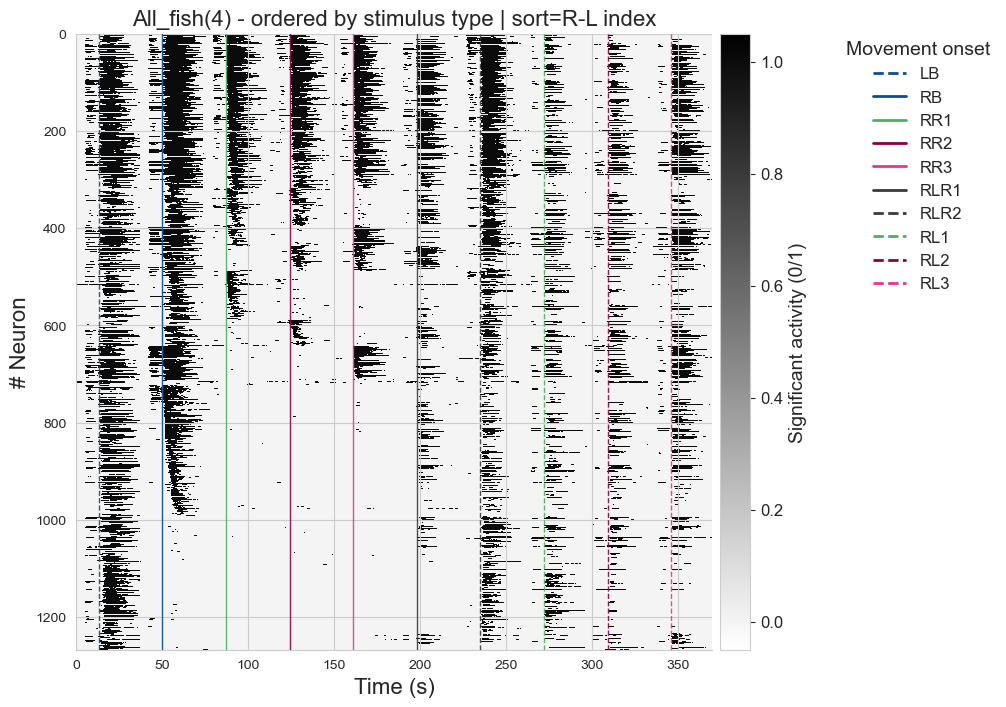

In [376]:
importlib.reload(at)
#{'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}
#{'LB': 1, 'RB': 2, 'RL1': 3, 'RL2': 4, 'RL3': 5, 'RLR1': 6, 'RLR2': 7, 'RR1': 8, 'RR2': 9, 'RR3': 10}
# 3 stimuli that define the pattern (e.g. FR1, FR2, FR3)
# stim_ids_for_pattern = [5, 6, 7]

stim_ids_for_pattern = [8, 9, 10]

# Build a dict of onsets per stimulus (you may already have this):
# onset_sec_by_stim = {1: onset_FL1, 2: onset_FL2, ..., 10: onset_RLB, ...}

# Stimulus you want to use for sorting the no_response group (e.g. RLB = 10)
stim_id_for_noresp_sort = 2

neuron_order, groups, mean_onset_pattern = at.build_neuron_order_groupwise_onset(
    response_type_by_id=response_type_by_id_concat,
    onset_sec_by_stim=onset_sec_by_id_concat,
    stim_ids_for_pattern=stim_ids_for_pattern,
    stim_id_for_noresp_sort=stim_id_for_noresp_sort,
)


stim_order = [1,2,8,9,10,6,7,3,4,5]
is_raster=True
combine_mode = "mean" # mean or concat
M_all= build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode,is_raster= is_raster)
print("Final matrix shape:", M_all.shape)


# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)

flat_matrix_all_fish = M_all   # (time, neurons) for raster_with_stimuli

fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='pca',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=neuron_order,       # or pass your own `neuron_order`
    sort_label='R-L index',         # optional label override
    is_binary=is_raster,         # True if you pass a 0/1 significance matrix
    figsize=(10, 8),
    fish_id="All_fish(4)",
)

# save_path.mkdir(parents=True, exist_ok=True)
# if is_raster is False:
#     out_png = save_path / f"delta_as_func_of_time_just_bouts_average.png"
# else:
#    out_png = save_path / f"binary_as_func_of_time_just_bouts_average.png"
# fig.savefig(out_png, dpi=600, bbox_inches="tight")
# print("✅ Saved:", out_png)

In [275]:
### raster r and left... Venn diagramm for both... neurons share for left and rigth...(organized like that)  delta F/F as a function of time... peack and area under the curve

Only 8: 104
Only 9: 51
Only 10: 72
8 & 9 only: 79
8 & 10 only: 41
9 & 10 only: 52
8 & 9 & 10: 323


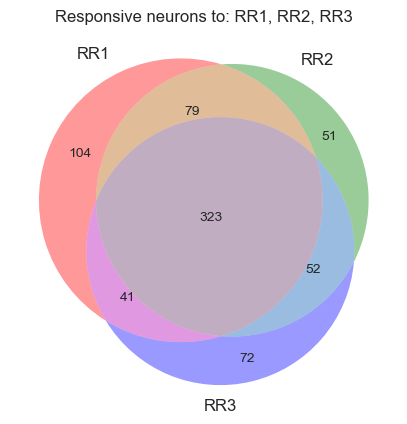

In [375]:
id_to_name = dict(zip(stimuli_ids, stimuli_names))

stim_ids = (8,9,10)
stim_labels = [id_to_name[sid] for sid in stim_ids]
at.plot_venn_3stim(
    response_type_by_id=response_type_by_id_concat,  # or per fish
    stim_ids=stim_ids,
    stim_labels=stim_labels,
)

In [277]:
def run_oneway_tests(values_dict, metric_name="AUC"):  # NEW
    """
    values_dict: dict[stim_id] -> array(shape (n_fish,))
    metric_name: only for printing ('AUC' or 'Peak')
    """
    groups = [values_dict[stim_id] for stim_id in new_stimuli_ids]
    n_groups = len(groups)

    print(f"\n===== {metric_name}: one-way comparison across stimuli =====")

    # NEW: will store significant pairs as (i, j, p_corrected)
    sig_pairs = []  # NEW

    # --- Normality per group (Shapiro) ---
    normal_flags = []
    for stim_id, g in zip(new_stimuli_ids, groups):
        g = np.asarray(g)
        if len(g) >= 3:
            stat, p_norm = stats.shapiro(g)
            print(f"Shapiro {metric_name} - {stim_id}: p = {p_norm:.3f}")
        else:
            p_norm = 1.0  # with very few fish Shapiro is unreliable, assume normal
            print(f"Shapiro {metric_name} - {stim_id}: N={len(g)}, skip (assume normal)")
        normal_flags.append(p_norm > alpha)

    all_normal = all(normal_flags)

    # --- Homogeneity of variances (Levene) ---
    if n_groups >= 2:
        stat_lev, p_lev = stats.levene(*groups)
        print(f"Levene {metric_name}: p = {p_lev:.3f}")
        equal_var = p_lev > alpha
    else:
        equal_var = True

    # --- Decision: ANOVA or Kruskal ---
    if all_normal and equal_var:
        print(f"Using ONE-WAY ANOVA for {metric_name} (parametric).")
        F, p_anova = stats.f_oneway(*groups)
        print(f"ANOVA F = {F:.3f}, p = {p_anova:.3e}")

        if p_anova < alpha:
            print(f"ANOVA significant, running Tukey HSD for {metric_name}...\n")
            data = np.concatenate(groups)
            group_labels = np.concatenate([
                np.repeat(lbl, len(g))
                for lbl, g in zip(labels, groups)
            ])
            tukey = pairwise_tukeyhsd(endog=data, groups=group_labels, alpha=alpha)
            print(tukey)

            # NEW: also compute pairwise t-tests with Bonferroni for plotting
            idx_pairs = list(itertools.combinations(range(n_groups), 2))  # NEW
            pvals = []                                                   # NEW
            for i, j in idx_pairs:                                       # NEW
                g1 = groups[i]                                           # NEW
                g2 = groups[j]                                           # NEW
                t_stat, p_raw = stats.ttest_ind(g1, g2, equal_var=True)  # NEW
                pvals.append(p_raw)                                      # NEW

            pvals = np.array(pvals)                                      # NEW
            m = len(pvals)                                               # NEW
            pvals_corr = np.minimum(pvals * m, 1.0)                      # NEW

            for (i, j), p_corr in zip(idx_pairs, pvals_corr):            # NEW
                if p_corr < alpha:                                       # NEW
                    sig_pairs.append((i, j, p_corr))                     # NEW
        else:
            print("No significant global effect, skipping post-hoc.")
    else:
        print(f"Using Kruskal–Wallis for {metric_name} (non-parametric).")
        H, p_kw = stats.kruskal(*groups)
        print(f"Kruskal H = {H:.3f}, p = {p_kw:.3e}")

        if p_kw < alpha:
            print(f"Kruskal significant, running Mann–Whitney post-hoc with Bonferroni...\n")
            # pairwise comparisons
            idx_pairs = list(itertools.combinations(range(n_groups), 2))
            pvals = []
            for i, j in idx_pairs:
                g1 = groups[i]
                g2 = groups[j]
                U, p_u = stats.mannwhitneyu(g1, g2, alternative="two-sided")
                pvals.append(p_u)

            pvals = np.array(pvals)
            m = len(pvals)
            pvals_corr = np.minimum(pvals * m, 1.0)  # Bonferroni

            for (i, j), p_raw, p_corr in zip(idx_pairs, pvals, pvals_corr):
                print(
                    f"{labels[i]} vs {labels[j]}: "
                    f"p_raw = {p_raw:.3e}, p_Bonf = {p_corr:.3e}"
                )
                # NEW: store only significant pairs for plotting
                if p_corr < alpha:                           # NEW
                    sig_pairs.append((i, j, p_corr))         # NEW
        else:
            print("No significant global effect, skipping post-hoc.")

    return sig_pairs  # NEW


C:\Users\suribear\AppData\Local\Temp\ipykernel_39640\1108399432.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_per_fish = np.trapz(seg, dx=dt, axis=1)   # (n_fish,)


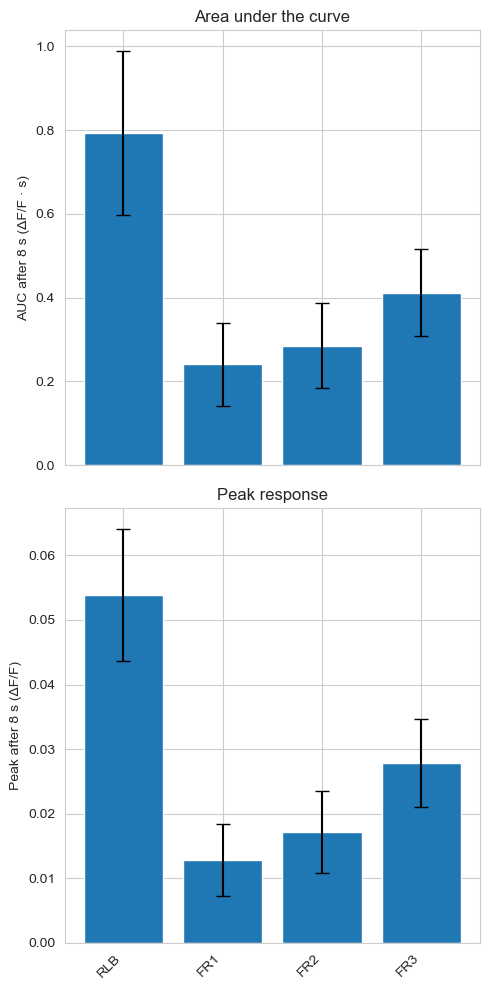


===== AUC after 9 s: one-way comparison across stimuli =====
Shapiro AUC after 9 s - 10: p = 0.185
Shapiro AUC after 9 s - 5: p = 0.426
Shapiro AUC after 9 s - 6: p = 0.076
Shapiro AUC after 9 s - 7: p = 0.160
Levene AUC after 9 s: p = 0.036
Using Kruskal–Wallis for AUC after 9 s (non-parametric).
Kruskal H = 5.581, p = 1.339e-01
No significant global effect, skipping post-hoc.

===== Peak after 9 s: one-way comparison across stimuli =====
Shapiro Peak after 9 s - 10: p = 0.227
Shapiro Peak after 9 s - 5: p = 0.562
Shapiro Peak after 9 s - 6: p = 0.103
Shapiro Peak after 9 s - 7: p = 0.351
Levene Peak after 9 s: p = 0.057
Using ONE-WAY ANOVA for Peak after 9 s (parametric).
ANOVA F = 6.106, p = 9.161e-03
ANOVA significant, running Tukey HSD for Peak after 9 s...

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   FL1    FL2   0.0107  0.746 -0.0206  0.0419  False
   FL1    LLB

In [278]:
#{'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}

stimuli_wanted = [9,4,5,6]  # positions in the list (0-based!)

M = {}  # new dict with selected mean_traces
new_stimuli_ids = []  # new list of ids
new_stimuli_names = []  # new list of names

for pos in stimuli_wanted:
    # id in your list at that position
    stim_id = stimuli_ids[pos]
    stim_name = stimuli_names[pos]

    # take the correct array from the dict
    M[stim_id] = concat_mean_all_neurons[stim_id]   # (n_fish, n_frames)

    # store id and name in new lists
    new_stimuli_ids.append(stim_id)
    new_stimuli_names.append(stim_name)

# ---------- NEW: compute AUC and peak after 9 s & store per fish ----------
import numpy as np       # NEW
import matplotlib.pyplot as plt  # NEW

t_after = 8.0            # NEW (seconds)
dt = 1.0 / fps_2p        # NEW
frame_9s = int(round(t_after * fps_2p))  # NEW: frame index for 9 s

auc_means = []           # NEW
auc_sems = []            # NEW
peak_means = []          # NEW
peak_sems = []           # NEW

auc_values = {}          # NEW: guarda AUC por pez para cada estímulo
peak_values = {}         # NEW: guarda pico por pez para cada estímulo

for stim_id in new_stimuli_ids:          # NEW
    traces = M[stim_id]                  # shape (n_fish, n_frames)
    if traces.ndim == 1:                 # NEW (por si acaso)
        traces = traces[None, :]

    n_fish, n_frames = traces.shape      # NEW
    if frame_9s >= n_frames:             # NEW: sanity check
        raise ValueError(
            f"9 s (frame {frame_9s}) está fuera del rango "
            f"para el estímulo {stim_id} con {n_frames} frames."
        )

    seg = traces[:, frame_9s:]           # NEW: todo lo que pasa después de 9 s

    # --- Área bajo la curva (AUC) por pez ---  # NEW
    auc_per_fish = np.trapz(seg, dx=dt, axis=1)   # (n_fish,)
    # --- Pico después de 9 s por pez ---       # NEW
    peak_per_fish = np.nanmax(seg, axis=1)        # (n_fish,)

    # Guarda para análisis estadístico        # NEW
    auc_values[stim_id] = auc_per_fish           # NEW
    peak_values[stim_id] = peak_per_fish         # NEW

    # Medias y SEM para el bar plot            # NEW
    auc_means.append(np.nanmean(auc_per_fish))
    peak_means.append(np.nanmean(peak_per_fish))

    if n_fish > 1:
        auc_sems.append(np.nanstd(auc_per_fish, ddof=1) / np.sqrt(n_fish))
        peak_sems.append(np.nanstd(peak_per_fish, ddof=1) / np.sqrt(n_fish))
    else:
        auc_sems.append(0.0)
        peak_sems.append(0.0)

auc_means = np.array(auc_means)       # NEW
auc_sems = np.array(auc_sems)         # NEW
peak_means = np.array(peak_means)     # NEW
peak_sems = np.array(peak_sems)       # NEW

# ---------- (igual que antes) bar plots with SEM ----------
x = np.arange(len(new_stimuli_ids))   # NEW

fig, axes = plt.subplots(2, 1, figsize=(5,10), sharex=True)  # NEW

# AUC bar plot
axes[0].bar(x, auc_means, yerr=auc_sems, capsize=5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(new_stimuli_names, rotation=45, ha="right")
axes[0].set_ylabel("AUC after 8 s (ΔF/F · s)")
axes[0].set_title("Area under the curve")

# Peak bar plot
axes[1].bar(x, peak_means, yerr=peak_sems, capsize=5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(new_stimuli_names, rotation=45, ha="right")
axes[1].set_ylabel("Peak after 8 s (ΔF/F)")
axes[1].set_title("Peak response")

fig.tight_layout()
plt.show()


# Run for AUC and peak
sig_pairs_auc  = run_oneway_tests(auc_values,  metric_name="AUC after 9 s")   # CHANGED
sig_pairs_peak = run_oneway_tests(peak_values, metric_name="Peak after 9 s")  # CHANGED


In [279]:
def add_significance_bars(ax, x, heights, sig_pairs, sems=None, line_frac=0.05):  # NEW
    """
    Draw significance bars with asterisks on a bar plot.

    ax       : matplotlib axis
    x        : array-like of x positions (same order as bars)
    heights  : list/array of bar heights
    sig_pairs: list of (i, j, p_corr) indices and p-values
    sems     : optional array of SEMs (to place bars above error bars)
    line_frac: vertical spacing as fraction of max height
    """
    if not sig_pairs:
        return

    x = np.asarray(x)
    heights = np.asarray(heights)
    if sems is not None:
        sems = np.asarray(sems)
        tops = heights + sems
    else:
        tops = heights

    y_max = tops.max()
    if y_max == 0:
        y_max = 1.0

    h = y_max * line_frac  # base height step

    for idx, (i, j, p_corr) in enumerate(sig_pairs):
        x1, x2 = x[i], x[j]
        y = y_max + h * (idx + 1)  # stack bars if multiple pairs

        # horizontal + vertical lines
        ax.plot([x1, x1, x2, x2],
                [y,  y + h*0.3, y + h*0.3, y],
                color="k", linewidth=1)

        # asterisks depending on p-value
        if p_corr < 0.001:
            stars = "***"
        elif p_corr < 0.01:
            stars = "**"
        elif p_corr < 0.05:
            stars = "*"
        else:
            stars = "ns"

        ax.text((x1 + x2) / 2.0, y + h*0.35, stars,
                ha="center", va="bottom", fontsize=10)


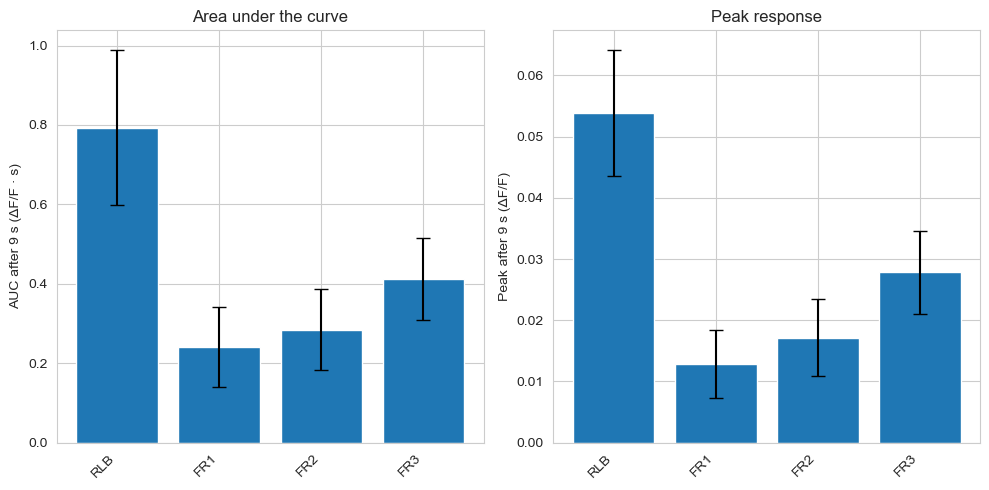

In [280]:
x = np.arange(len(new_stimuli_ids))

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

# --- AUC bar plot ---
bars_auc = axes[0].bar(x, auc_means, yerr=auc_sems, capsize=5)  # CHANGED
axes[0].set_xticks(x)
axes[0].set_xticklabels(new_stimuli_names, rotation=45, ha="right")
axes[0].set_ylabel("AUC after 9 s (ΔF/F · s)")
axes[0].set_title("Area under the curve")

# --- Peak bar plot ---
bars_peak = axes[1].bar(x, peak_means, yerr=peak_sems, capsize=5)  # CHANGED
axes[1].set_xticks(x)
axes[1].set_xticklabels(new_stimuli_names, rotation=45, ha="right")
axes[1].set_ylabel("Peak after 9 s (ΔF/F)")
axes[1].set_title("Peak response")

# --- NEW: add significance bars using the results from run_oneway_tests ---
heights_auc  = [b.get_height() for b in bars_auc]   # NEW
heights_peak = [b.get_height() for b in bars_peak]  # NEW

add_significance_bars(axes[0], x, heights_auc,  sig_pairs_auc,  sems=auc_sems)   # NEW
add_significance_bars(axes[1], x, heights_peak, sig_pairs_peak, sems=peak_sems)  # NEW

fig.tight_layout()
plt.show()


In [387]:
### Shares neurons by flickers

#{'LB': 1, 'RB': 2, 'RL1': 3, 'RL2': 4, 'RL3': 5, 'RLR1': 6, 'RLR2': 7, 'RR1': 8, 'RR2': 9, 'RR3': 10}
def compare_stim8_with_567(response_type_by_id):
    """
    Compare responsiveness to stim 8 vs stims 5, 6, 7.
     #{'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}
    Returns
    -------
    idx_8_and_567 : np.ndarray
        Neuron indices that are responsive to stim 8
        AND to at least one of stim 5, 6, or 7.
    idx_any_567 : np.ndarray
        Neuron indices that are responsive to at least one
        of stim 5, 6, or 7 (1 or 2).
    masks : dict
        Dictionary with boolean masks if you want them.
    """
    resp_by_id = {}  # will hold boolean masks

    for stim_id, arr in response_type_by_id.items():
    # arr is (n_neurons,) for this stimulus
        resp_by_id[stim_id] = (arr != 0)

    # responsive to at least one of 5, 6, 7
    resp_567 = resp_by_id[5] | resp_by_id[6] | resp_by_id[7]# (n_neurons,)
    resp_8_9 = resp_by_id[8] | resp_by_id[9]
    resp_123 = resp_by_id[1] | resp_by_id[2] | resp_by_id[3]
    resp_4_10 = resp_by_id[4] | resp_by_id[10]
    resp_3_4_5 = resp_by_id[3] | resp_by_id[4] | resp_by_id[5]
    resp_8_9_10 = resp_by_id[8] | resp_by_id[9] | resp_by_id[10]
    resp_7_1 = resp_by_id[7] & resp_by_id[1]
    resp_7_2 = resp_by_id[7] & resp_by_id[2]
    # neurons that respond to 8 AND to at least one of 5/6/7
    mask_8_and_567 = resp_8_9 & resp_567
    mask_4_and_123 = resp_4_10 & resp_123
    mask_567_and_123 = resp_567 & resp_123
    mask_345_and_8910 = resp_3_4_5  & resp_8_9_10
    mask_71_or_72 =  resp_7_1 |  resp_7_2

    idx_8_and_567 = np.where(mask_8_and_567)[0]
    idx_any_567   = np.where(resp_567)[0]
    idx_any_123   = np.where(resp_123)[0]
    idx_4_and_123 = np.where(mask_4_and_123)[0]
    indx_567_and_123 = np.where(mask_567_and_123)[0]
    indx_345_and_8910 = np.where(mask_345_and_8910 )[0]
    indx_71_or_72   = np.where(mask_71_or_72)[0]

    masks = {
        "resp_8": resp_by_id[8],
        "resp_567": resp_567,
        "8_and_567": mask_8_and_567,
    }

    return idx_8_and_567, idx_any_567, idx_any_123, idx_4_and_123, masks, indx_567_and_123, indx_345_and_8910, indx_71_or_72

idx_8_and_567, idx_any_567, idx_any_123, idx_4_and_123, masks, indx_567_and_123,indx_345_and_8910, indx_71_or_72  = compare_stim8_with_567(response_type_by_id_concat)

print("Neurons responsive to 8 AND (5 or 6 or 7):", idx_8_and_567.shape[0])
print("Neurons responsive to at least one of 5,6,7:", idx_any_567.shape[0])

### organized this neurons by L_R_ index




Neurons responsive to 8 AND (5 or 6 or 7): 608
Neurons responsive to at least one of 5,6,7: 1027


1267
Final matrix shape: (1267, 740)


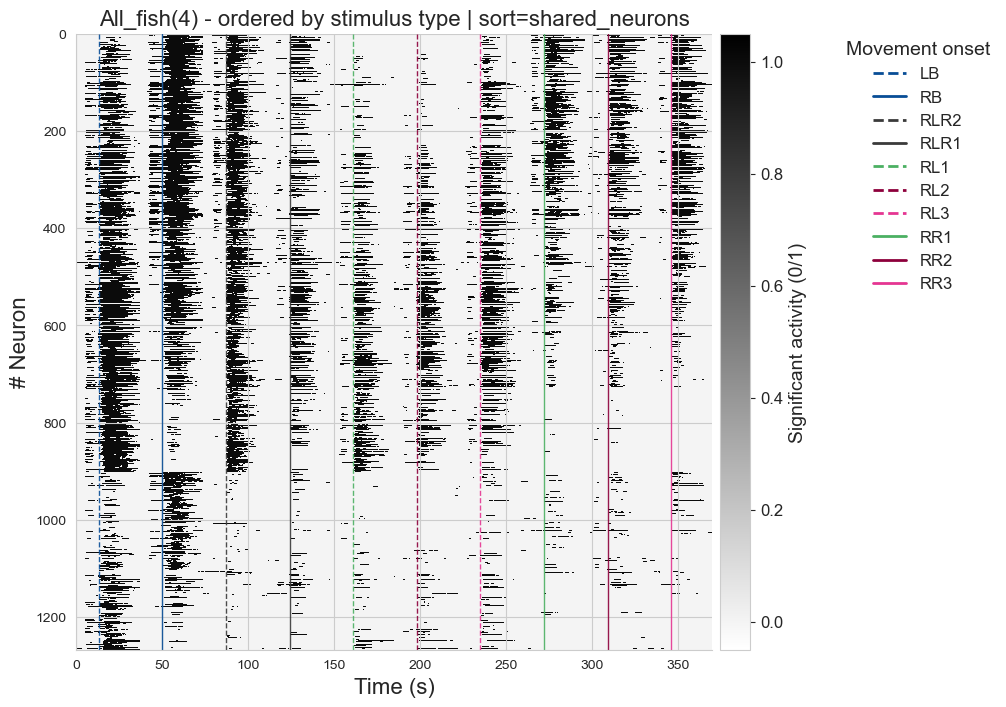

In [389]:
## plot response to both side rocking position 2




# flat_matrix_all_fish: shape (n_neurons, something)
n_neurons, _ = flat_matrix_all_fish.shape
print(n_neurons)

TI = np.asarray(TI)  # ensure it's a numpy array of shape (n_neurons,)

# 1) Define sets of neurons
all_neurons = np.arange(n_neurons)
flicker_neurons = np.asarray(indx_71_or_72, dtype=int)

# non-flicker = all minus flicker
non_flicker_neurons = np.setdiff1d(all_neurons, flicker_neurons)

# 2) Sort each group by TI (here: from 1 → -1, i.e. descending)
flicker_order = flicker_neurons[np.argsort(TI[flicker_neurons])[::-1]]
non_flicker_order = non_flicker_neurons[np.argsort(TI[non_flicker_neurons])[::-1]]

# 3) Concatenate both groups
neuron_order = np.concatenate([flicker_order, non_flicker_order])

#{'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}

# 3 stimuli that define the pattern (e.g. FR1, FR2, FR3)
# stim_ids_for_pattern = [5, 6, 7]

stim_order = [1,2,7,6,3,4,5,8,9,10]
is_raster=True
combine_mode = "mean" # mean or concat
M_all= build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode,is_raster= is_raster)
print("Final matrix shape:", M_all.shape)


# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)

flat_matrix_all_fish = M_all   # (time, neurons) for raster_with_stimuli

fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='pca',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=neuron_order,       # or pass your own `neuron_order`
    sort_label='shared_neurons',         # optional label override
    is_binary=is_raster,         # True if you pass a 0/1 significance matrix
    figsize=(10, 8),
    fish_id="All_fish(4)",
)

# save_path.mkdir(parents=True, exist_ok=True)
# if is_raster is False:
#     out_png = save_path / f"delta_as_func_of_time_just_bouts_average.png"
# else:
#    out_png = save_path / f"binary_as_func_of_time_just_bouts_average.png"
# fig.savefig(out_png, dpi=600, bbox_inches="tight")
# print("✅ Saved:", out_png)


1267
Final matrix shape: (1267, 740)


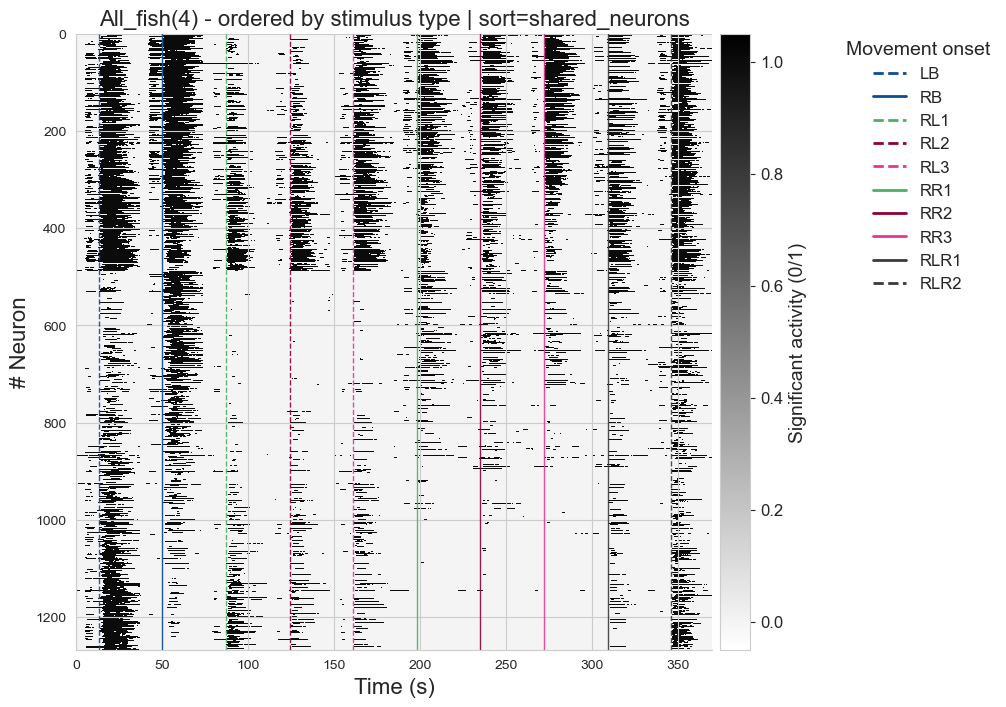

In [384]:
# flat_matrix_all_fish: shape (n_neurons, something)
n_neurons, _ = flat_matrix_all_fish.shape
print(n_neurons)

TI = np.asarray(TI)  # ensure it's a numpy array of shape (n_neurons,)

# 1) Define sets of neurons
all_neurons = np.arange(n_neurons)
flicker_neurons = np.asarray(indx_345_and_8910, dtype=int)

# non-flicker = all minus flicker
non_flicker_neurons = np.setdiff1d(all_neurons, flicker_neurons)

# 2) Sort each group by TI (here: from 1 → -1, i.e. descending)
flicker_order = flicker_neurons[np.argsort(TI[flicker_neurons])[::-1]]
non_flicker_order = non_flicker_neurons[np.argsort(TI[non_flicker_neurons])[::-1]]

# 3) Concatenate both groups
neuron_order = np.concatenate([flicker_order, non_flicker_order])

#{'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}

# 3 stimuli that define the pattern (e.g. FR1, FR2, FR3)
# stim_ids_for_pattern = [5, 6, 7]

stim_order = [1,2,3,4,5,8,9,10,6,7]
is_raster=True
combine_mode = "mean" # mean or concat
M_all= build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode,is_raster= is_raster)
print("Final matrix shape:", M_all.shape)


# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)

flat_matrix_all_fish = M_all   # (time, neurons) for raster_with_stimuli

fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='pca',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=neuron_order,       # or pass your own `neuron_order`
    sort_label='shared_neurons',         # optional label override
    is_binary=is_raster,         # True if you pass a 0/1 significance matrix
    figsize=(10, 8),
    fish_id="All_fish(4)",
)

# save_path.mkdir(parents=True, exist_ok=True)
# if is_raster is False:
#     out_png = save_path / f"delta_as_func_of_time_just_bouts_average.png"
# else:
#    out_png = save_path / f"binary_as_func_of_time_just_bouts_average.png"
# fig.savefig(out_png, dpi=600, bbox_inches="tight")
# print("✅ Saved:", out_png)


Final matrix shape: (2148, 148)


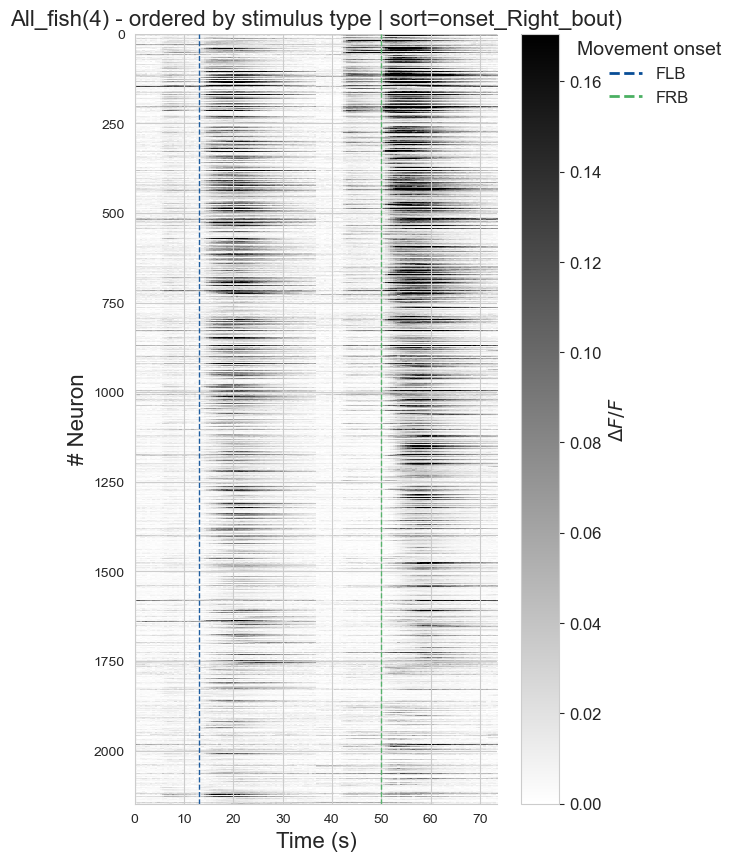

In [287]:
### organize by onset....'

#{'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}

# 3) Concatenate both groups
neuron_order = np.argsort(onset_sec_by_id_concat[10])

#{'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}

# 3 stimuli that define the pattern (e.g. FR1, FR2, FR3)
# stim_ids_for_pattern = [5, 6, 7]

stim_order = [4,8]
is_raster=False
combine_mode = "mean" # mean or concat
M_all= build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode,is_raster= is_raster)
print("Final matrix shape:", M_all.shape)


# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)

flat_matrix_all_fish = M_all   # (time, neurons) for raster_with_stimuli

fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='pca',      # or "pca", "hier", etc.
    n_clusters=3,
    random_state=0,
    neuron_order=neuron_order,       # or pass your own `neuron_order`
    sort_label='onset_Right_bout)',         # optional label override
    is_binary=is_raster,         # True if you pass a 0/1 significance matrix
    figsize=(6, 10),
    fish_id="All_fish(4)",
)


In [327]:
#### correlation betweeen onset and peak
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def onset_vs_response_corr_and_plot(
    stim_id,
    concat_mean_all_neurons,
    onset_sec_by_id_concat,
    fps,
    costum_val=None,
    window_sec=8.0,
    metric="auc",     # "auc" or "peak"
    title_prefix="Stim"
):
    """
    For one stimulus:
      - takes per-neuron mean traces and per-neuron onset (sec),
      - computes response metric in [0, window_sec] after stim onset,
      - correlates onset vs response,
      - and plots a scatter + regression line.

    Returns: r, p, onset_valid, resp_valid
    """

    # --- Get data for this stimulus ---
    traces = np.asarray(concat_mean_all_neurons[stim_id])   # (n_neurons, n_frames)
    onset_sec = np.asarray(onset_sec_by_id_concat[stim_id]) # (n_neurons,)

    if traces.ndim != 2:
        raise ValueError("concat_mean_all_neurons[stim_id] must be (n_neurons, n_frames)")
    n_neurons, n_frames = traces.shape

    # --- Window in frames (0 -> window_sec) ---
    win_frames = int(round(window_sec * fps))
    win_frames = min(win_frames, n_frames)  # safety
    traces_win = traces[:, :win_frames]     # (n_neurons, win_frames)

    # --- Compute response metric per neuron ---
    if metric.lower() == "auc":
        # AUC in 'signal * seconds'
        resp_vals = np.trapz(traces_win, dx=1.0/fps, axis=1)
        y_label = f"AUC (0–{window_sec:.1f} s)"
    elif metric.lower() == "peak":
        resp_vals = np.nanmax(traces_win, axis=1)
        y_label = f"Peak (0–{window_sec:.1f} s)"
    else:
        raise ValueError("metric must be 'auc' or 'peak'")

    if costum_val is None:
      onset_sec = onset_sec
    else:
       onset_sec = costum_val
    # --- Remove NaNs / bad values ---
    mask = np.isfinite(onset_sec) & np.isfinite(resp_vals)
    onset_valid = onset_sec[mask]
    resp_valid = resp_vals[mask]

    if onset_valid.size < 2:
        raise ValueError("Not enough valid neurons to compute correlation.")

    # --- Correlation ---
    r, p = pearsonr(onset_valid, resp_valid)

    # --- Plot scatter ---
    plt.figure()
    plt.scatter(onset_valid, resp_valid, alpha=0.8,color="seagreen")

    # Regression line
    m, b = np.polyfit(onset_valid, resp_valid, 1)
    x_line = np.linspace(onset_valid.min(), onset_valid.max(), 100)
    plt.plot(x_line, m * x_line + b, color="orchid", linewidth=2)

    if costum_val is None:
        plt.xlabel("Onset (s)")
    else:
        plt.xlabel("Left-Rigth Index (s)")
    plt.ylabel(y_label)
    plt.title(f"{title_prefix} {stim_id}: r = {r:.2f}, p = {p:.3g}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return r, p, onset_valid, resp_valid


C:\Users\suribear\AppData\Local\Temp\ipykernel_39640\3877547936.py:42: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  resp_vals = np.trapz(traces_win, dx=1.0/fps, axis=1)


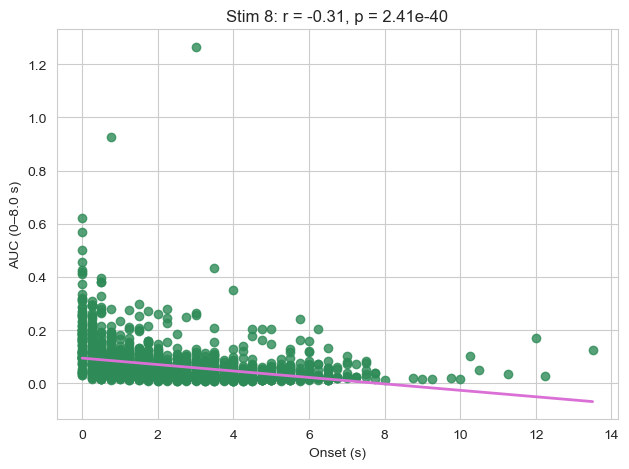

Stim 1 – onset vs AUC:
  r = -0.3076239535334183  p = 2.4111202417025956e-40


In [329]:
fps = fps_2p  # or whatever your frame rate is
#{'FL1': 1, 'FL2': 2, 'FL3': 3, 'FLB': 4, 'FR1': 5, 'FR2': 6, 'FR3': 7, 'FRB': 8, 'LLB': 9, 'RLB': 10}

r_auc, p_auc, onset_s, auc_vals = onset_vs_response_corr_and_plot(
    stim_id=8,
    concat_mean_all_neurons=concat_mean_traces,
    onset_sec_by_id_concat=onset_sec_by_id_concat,
    costum_val=None,
    fps=fps,
    window_sec=8.0,
    metric="AUC",
    title_prefix="Stim"
)

print("Stim 1 – onset vs AUC:")
print("  r =", r_auc, " p =", p_auc)
